In [1]:
# General purpose
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Signal processing
from scipy.io import loadmat 
from scipy.ndimage import convolve1d
from scipy.signal import butter
from scipy.signal import sosfiltfilt
from scipy.signal import welch

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
# Hyperparameter tuning
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
# Feature selection
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest

np.random.seed(42)

In [ ]:
FILEPATH_MAT = "data/S2_A1_E1.mat"
FILEPATH_CSV = "data/data.csv"

TRAIN_PCT = 0.75
VAL_PCT = 0.05
TEST_PCT = 0.20

assert TRAIN_PCT + VAL_PCT + TEST_PCT == 1.0, "TRAIN_PCT, VAL_PCT and TEST_PCT must sum to 1.0"

In [3]:
data = loadmat(FILEPATH_MAT)

print("Dataset variables:")
print([key for key in data.keys() if not key.startswith("__")])

emg = data["emg"]
print("EMG data dimension: {}".format(emg.shape))
print("EMG data type: {}".format(type(emg)))

stimulus = data['restimulus']
repetition = data['rerepetition']

Dataset variables:
['subject', 'exercise', 'stimulus', 'emg', 'glove', 'restimulus', 'repetition', 'rerepetition']
EMG data dimension: (100686, 10)
EMG data type: <class 'numpy.ndarray'>


In [4]:
N_STIMULI = len(np.unique(stimulus)) - 1 # -1 because 0 is the resting condition
N_REPETITIONS = len(np.unique(repetition)) - 1 # -1 because 0 is not a repetition
N_CHANNELS = emg.shape[1]

MOV_MEAN_LENGTH = 100
mov_mean_weights = np.ones(MOV_MEAN_LENGTH) / MOV_MEAN_LENGTH

#initializing the data structure
emg_windows = [[None for repetition_idx in range(N_REPETITIONS)] for stimuli_idx in range(N_STIMULI)] 
emg_envelopes = [[None for repetition_idx in range(N_REPETITIONS)] for stimuli_idx in range(N_STIMULI)]

for stimuli_idx in range(N_STIMULI):
    for repetition_idx in range(N_REPETITIONS):
        idx = np.logical_and(stimulus == stimuli_idx + 1, repetition == repetition_idx + 1).flatten()
        emg_windows[stimuli_idx][repetition_idx] = emg[idx, :]
        emg_envelopes[stimuli_idx][repetition_idx] = convolve1d(emg_windows[stimuli_idx][repetition_idx], mov_mean_weights, axis=0)

## Data Inspection

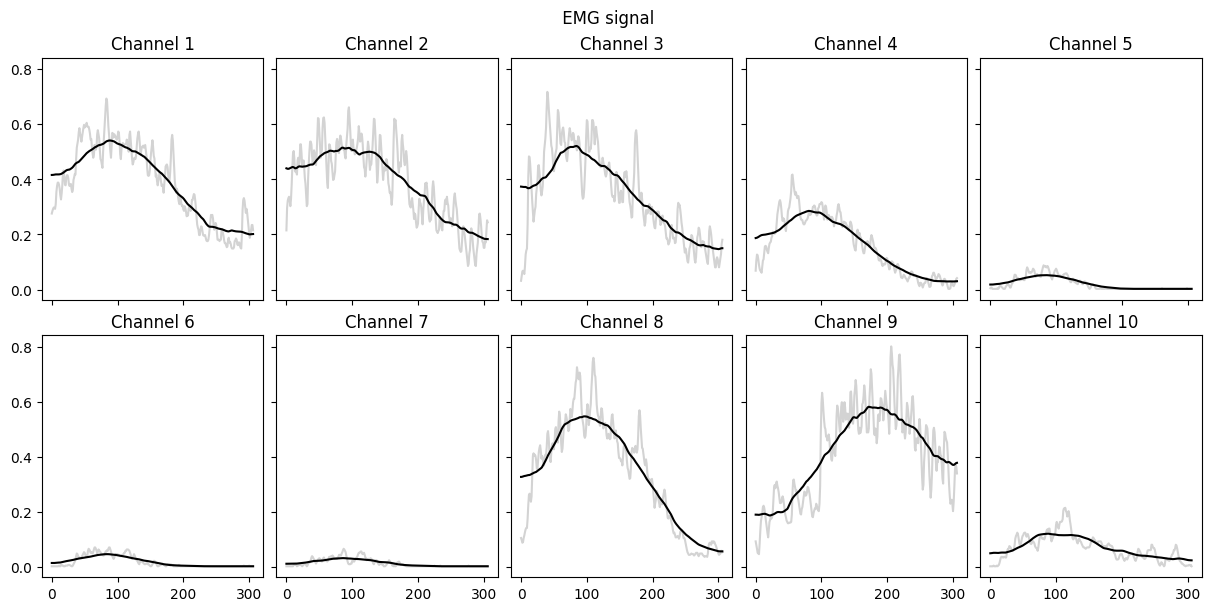

In [5]:
# Now we plot all the channels on the same y-scale
fig, ax = plt.subplots(2, 5, figsize=(12, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

number_of_emg_channels = emg.shape[-1]

for channel_idx in range(number_of_emg_channels): 
    # plot EMG signal
    ax[channel_idx].plot(emg_windows[0][0][:, channel_idx], color='lightgray')
    ax[channel_idx].set_title(f"Channel {channel_idx+1}")

    # Plot Enveloped signal
    ax[channel_idx].plot(emg_envelopes[0][0][:, channel_idx], color='black')
    ax[channel_idx].set_title(f"Channel {channel_idx+1}")
plt.suptitle(" EMG signal")
plt.show()

Number of channels: 10, Number of stimuli: 12, Number of repetitions: 10


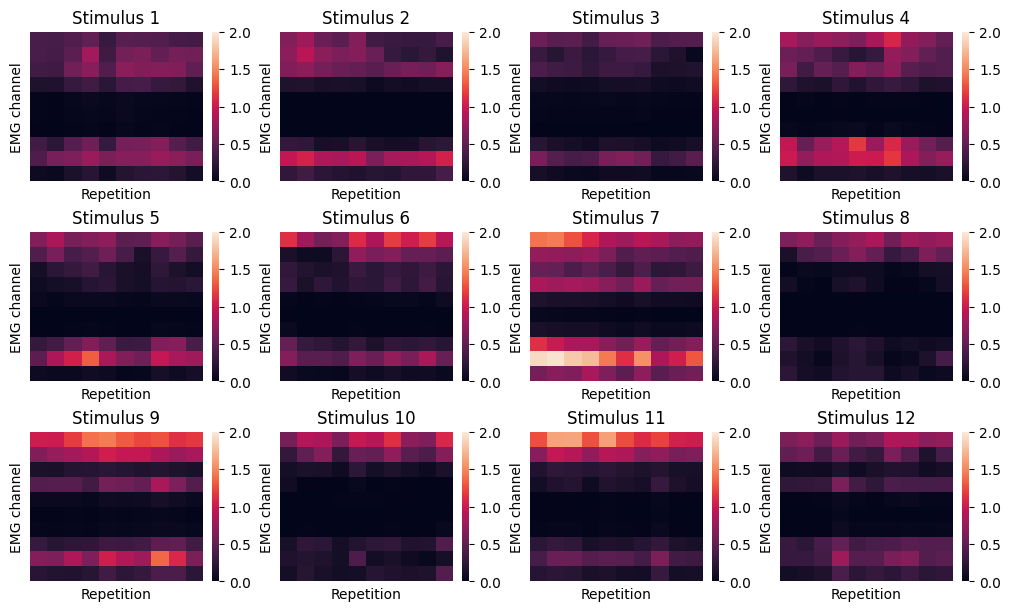

In [6]:
print(f"Number of channels: {N_CHANNELS}, Number of stimuli: {N_STIMULI}, Number of repetitions: {N_REPETITIONS}")
emg_average_activations = np.zeros((N_CHANNELS, N_STIMULI, N_REPETITIONS))
for stimuli_idx in range(N_STIMULI):
    for repetition_idx in range(N_REPETITIONS):
        #mean across time for each channel
        emg_average_activations[:, stimuli_idx, repetition_idx] = np.mean(emg_envelopes[stimuli_idx][repetition_idx], axis=0) 

fig, ax = plt.subplots(3, 4, figsize=(10, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

for stimuli_idx in range(N_STIMULI):
    sns.heatmap(np.squeeze(emg_average_activations[:, stimuli_idx, :]), 
                ax=ax[stimuli_idx],
                vmin=0, 
                vmax=2.0,
                xticklabels=False, 
                yticklabels=False, 
                cbar = True)
    ax[stimuli_idx].title.set_text("Stimulus " + str(stimuli_idx + 1))
    ax[stimuli_idx].set_xlabel("Repetition")
    ax[stimuli_idx].set_ylabel("EMG channel")

In [ ]:
def build_dataset_from_ninapro(emg, stimulus, repetition, features=[]):
    # Calculate the number of unique stimuli and repetitions, subtracting 1 to exclude the resting condition
    n_stimuli = np.unique(stimulus).size - 1
    n_repetitions = np.unique(repetition).size - 1
    # Total number of samples is the product of stimuli and repetitions
    n_samples = n_stimuli * n_repetitions
    
    # Number of channels in the EMG data
    n_channels = emg.shape[1]
    # Calculate the total number of features by summing the number of channels for each feature
    n_features = sum(n_channels for feature in features)
    
    # Initialize the dataset and labels arrays with zeros
    dataset = np.zeros((n_samples, n_features))
    labels = np.zeros(n_samples)
    current_sample_index = 0
    
    # Loop over each stimulus and repetition to extract features
    for i in range(n_stimuli):
        for j in range(n_repetitions):
            # Assign the label for the current sample
            labels[current_sample_index] = i + 1
            # Calculate the current sample index based on stimulus and repetition
            current_sample_index = i * n_repetitions + j
            current_feature_index = 0
            # Select the time steps corresponding to the current stimulus and repetition
            selected_tsteps = np.logical_and(stimulus == i + 1, repetition == j + 1).squeeze()
            
            # Loop over each feature function provided
            for feature in features:
                # Determine the indices in the dataset where the current feature will be stored
                selected_features = np.arange(current_feature_index, current_feature_index + n_channels)
                # Apply the feature function to the selected EMG data and store the result
                dataset[current_sample_index, selected_features] = feature(emg[selected_tsteps, :])
                # Update the feature index for the next feature
                current_feature_index += n_channels

                # plot the selected emg for debugging
                """ plt.figure(figsize=(10, 3))
                plt.plot(emg[selected_tsteps, :])
                plt.title(f"EMG Data for Stimulus {i+1}, Repetition {j+1}")
                plt.xlabel("Time Steps")
                plt.ylabel("Amplitude")
                plt.show() """

            # Move to the next sample
            current_sample_index += 1
            
    # Return the constructed dataset and corresponding labels
    return dataset, labels


def build_dataset_from_precalc(precalc_features, feature_names):
    """
    Build dataset from pre-calculated features.
    
    Parameters:
    - precalc_features: dict mapping feature_name -> array of shape (n_samples, n_channels)
    - feature_names: list of feature names to include
    
    Returns:
    - dataset: array of shape (n_samples, n_features)
    """
    n_samples = next(iter(precalc_features.values())).shape[0]
    n_channels = next(iter(precalc_features.values())).shape[1]
    n_features = len(feature_names) * n_channels
    
    dataset = np.zeros((n_samples, n_features))
    
    for idx, fname in enumerate(feature_names):
        start_col = idx * n_channels
        end_col = start_col + n_channels
        dataset[:, start_col:end_col] = precalc_features[fname]
    
    return dataset

In [8]:

# Mean absolute value (MAV)
mav = lambda x: np.mean(np.abs(x), axis=0)
# Standard Deviation (STD)
std = lambda x: np.std(x, axis=0)
# Maximum absolute Value (MaxAV)
maxav = lambda x: np.max(np.abs(x), axis=0)
# Root mean square (RMS)
rms = lambda x: np.sqrt(np.mean(x**2, axis=0))
# Waveform length (WL)
wl = lambda x: np.sum(np.abs(np.diff(x, axis=0)), axis=0)
# Slope sign changes (SSC)
ssc = lambda x: np.sum((np.diff(x, axis=0)[:-1, :] * np.diff(x, axis=0)[1:, :]) < 0, axis=0)

# Additional features from the paper:
# Zero Crossings (ZC) with threshold to reduce noise sensitivity
def zc(x, th=0.01):
    # x: (T, C)
    dx = x[:-1, :] * x[1:, :] # product of consecutive samples to find sign changes
    crossings = (dx < 0) & (np.abs(x[:-1, :]) > th) | (np.abs(x[1:, :]) > th) # check for sign change and threshold
    return np.sum(crossings, axis=0).astype(float)

# Willison Amplitude (WAMP) - counts of large amplitude differences
def wamp(x, th=0.02):
    return np.sum(np.abs(np.diff(x, axis=0)) > th, axis=0).astype(float)

# Simple FD features: mean frequency and median frequency per channel
def mean_freq(x, fs=2000):
    f, Pxx = welch(x, fs=fs, axis=0, nperseg=min(256, max(8, x.shape[0])))
    Psum = np.sum(Pxx, axis=0) + 1e-12
    return np.sum(f[:, None] * Pxx, axis=0) / Psum

def median_freq(x, fs=2000):
    f, Pxx = welch(x, fs=fs, axis=0, nperseg=min(256, max(8, x.shape[0])))
    Pcum = np.cumsum(Pxx, axis=0)
    total = Pcum[-1, :] + 1e-12
    med = np.zeros(x.shape[1])
    for c in range(x.shape[1]):
        idx = np.searchsorted(Pcum[:, c], total[c] / 2.0)
        med[c] = f[min(idx, f.size - 1)]
    return med

# Combine all features into a dict (keys are used later for selecting subsets)
all_features = {
    "mav": mav,
    "std": std,
    "maxav": maxav,
    "rms": rms,
    "wl": wl,
    "ssc": ssc,
    "zc": zc,
    "wamp": wamp,
    "mean_freq": mean_freq,
    "median_freq": median_freq,
}

#TODO: Feel free to add more features, e.g. frequency domain features. (See https://doi.org/10.3390/s19204596 and https://doi.org/10.1088/0967-3334/24/2/307)

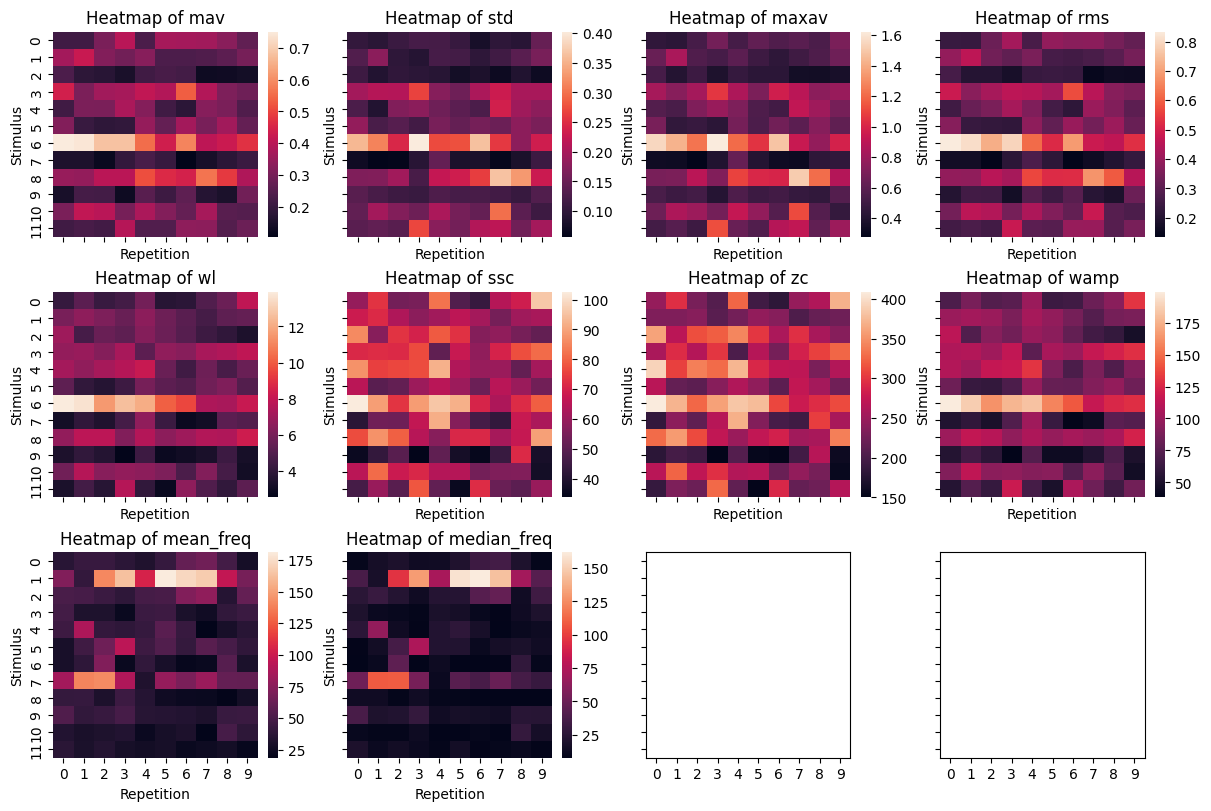

In [9]:
# Visualise all feature accross all trials as a heatmap

fig, ax = plt.subplots(3, 4, figsize=(12, 8), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

for ax_idx, (feature_name, feature_func) in enumerate(all_features.items()):
    feature_values = []
    for stimuli_idx in range(N_STIMULI):
        for repetition_idx in range(N_REPETITIONS):
            mask = np.logical_and(stimulus == stimuli_idx + 1, repetition == repetition_idx + 1).flatten()
            feature_value = feature_func(emg[mask, :])
            feature_values.append(np.mean(feature_value))  # Mean across channels

    sns.heatmap(np.array(feature_values).reshape(N_STIMULI, N_REPETITIONS), annot=False, fmt=".2f", ax=ax[ax_idx])
    ax[ax_idx].set_title(f"Heatmap of {feature_name}")
    ax[ax_idx].set_xlabel("Repetition")
    ax[ax_idx].set_ylabel("Stimulus")
plt.show()

In [10]:
# Pre-calculate all features once to avoid redundant computation
print("Pre-calculating all features...")
t_start = time.time()

n_stimuli = np.unique(stimulus).size - 1
n_repetitions = np.unique(repetition).size - 1
n_samples = n_stimuli * n_repetitions
n_channels = emg.shape[1]

# Store pre-calculated features: dict[feature_name] -> array of shape (n_samples, n_channels)
precalc_features = {name: np.zeros((n_samples, n_channels)) for name in all_features.keys()}
precalc_labels = np.zeros(n_samples)

sample_idx = 0
for i in range(n_stimuli):
    for j in range(n_repetitions):
        precalc_labels[sample_idx] = i + 1
        selected_tsteps = np.logical_and(stimulus == i + 1, repetition == j + 1).squeeze()
        
        for feature_name, feature_func in all_features.items():
            precalc_features[feature_name][sample_idx, :] = feature_func(emg[selected_tsteps, :])
        
        sample_idx += 1

print(f"Feature pre-calculation completed in {time.time() - t_start:.2f} seconds")
print(f"Stored {len(precalc_features)} features for {n_samples} samples with {n_channels} channels each")


Pre-calculating all features...
Feature pre-calculation completed in 0.23 seconds
Stored 10 features for 120 samples with 10 channels each


### Train-Val-Test Basic

In [24]:
dataset, labels = build_dataset_from_ninapro(
    emg=emg,
    stimulus=stimulus,
    repetition=repetition,
    features=all_features.values()
)

# Split the dataset into train+validation
X_trainval, X_test, y_trainval, y_test = train_test_split(dataset, labels, test_size=TEST_PCT, random_state=42)

# Split train+validation into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=VAL_PCT/(TRAIN_PCT+VAL_PCT), random_state=42)

print(f"Dataset splits:")
print(f"  Training: {len(y_train)} samples ({len(y_train)/len(labels)*100:.1f}%)")
print(f"  Validation: {len(y_val)} samples ({len(y_val)/len(labels)*100:.1f}%)")
print(f"  Test: {len(y_test)} samples ({len(y_test)/len(labels)*100:.1f}%)")

# Normalizing the data
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train)
X_val_z = scaler.transform(X_val)
X_test_z = scaler.transform(X_test)

# Train Gradient Boosting classifier
clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train_z, y_train)

# Evaluate on validation set
y_val_pred = clf.predict(X_val_z)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation accuracy: {val_accuracy:.4f}")

# Evaluate on test set
y_test_pred = clf.predict(X_test_z)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test accuracy: {test_accuracy:.4f}")



Dataset splits:
  Training: 96 samples (80.0%)
  Validation: 12 samples (10.0%)
  Test: 12 samples (10.0%)
Validation accuracy: 0.6667
Test accuracy: 0.7500


## Finding the best combination of features

In [13]:
from itertools import combinations

feature_names = list(all_features.keys())

# Generate all non-empty feature subsets
all_feature_sets = []
for r in range(1, len(feature_names) + 1):
    for combo in combinations(feature_names, r):
        all_feature_sets.append(combo)

print(f"Total number of feature subsets: {len(all_feature_sets)}")
print([set for set in all_feature_sets])

one_feature_set = [all_feature_sets[-1]]
print(f"Total number of feature subsets: {len(one_feature_set)}")
print([set for set in one_feature_set])

Total number of feature subsets: 1023
[('mav',), ('std',), ('maxav',), ('rms',), ('wl',), ('ssc',), ('zc',), ('wamp',), ('mean_freq',), ('median_freq',), ('mav', 'std'), ('mav', 'maxav'), ('mav', 'rms'), ('mav', 'wl'), ('mav', 'ssc'), ('mav', 'zc'), ('mav', 'wamp'), ('mav', 'mean_freq'), ('mav', 'median_freq'), ('std', 'maxav'), ('std', 'rms'), ('std', 'wl'), ('std', 'ssc'), ('std', 'zc'), ('std', 'wamp'), ('std', 'mean_freq'), ('std', 'median_freq'), ('maxav', 'rms'), ('maxav', 'wl'), ('maxav', 'ssc'), ('maxav', 'zc'), ('maxav', 'wamp'), ('maxav', 'mean_freq'), ('maxav', 'median_freq'), ('rms', 'wl'), ('rms', 'ssc'), ('rms', 'zc'), ('rms', 'wamp'), ('rms', 'mean_freq'), ('rms', 'median_freq'), ('wl', 'ssc'), ('wl', 'zc'), ('wl', 'wamp'), ('wl', 'mean_freq'), ('wl', 'median_freq'), ('ssc', 'zc'), ('ssc', 'wamp'), ('ssc', 'mean_freq'), ('ssc', 'median_freq'), ('zc', 'wamp'), ('zc', 'mean_freq'), ('zc', 'median_freq'), ('wamp', 'mean_freq'), ('wamp', 'median_freq'), ('mean_freq', 'median

### Train-Test CV

In [32]:
""" param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [1, 3, 5],
    "subsample": [0.8, 1.0]
} """
param_grid = {
    "n_estimators": [100],
    "learning_rate": [0.1],
    "max_depth": [3],
    "subsample": [1.0]
}

CV = 3
TEST_SIZE = 0.3

feature_set = all_feature_sets

# store results for later analysis / visualisation
results = []

n_iterations = len(feature_set)
t0 = time.time()

for i, subset in enumerate(feature_set):

    # Build dataset from pre-calculated features (much faster!)
    dataset = build_dataset_from_precalc(precalc_features, list(subset))
    labels = precalc_labels

    X_train, X_test, y_train, y_test = train_test_split(dataset, labels, test_size=TEST_SIZE, random_state=42)
    scaler = StandardScaler()
    X_train_z = scaler.fit_transform(X_train)
    X_test_z = scaler.transform(X_test)

    grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=CV, n_jobs=-1)
    grid.fit(X_train_z, y_train)

    y_pred = grid.predict(X_test_z)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "feature_set": "+".join(subset),
        "subset_tuple": subset,
        "n_features": dataset.shape[1],
        "best_params": grid.best_params_,
        "best_cv_score": grid.best_score_,
        "test_accuracy": acc,
        "confusion_matrix": cm,
        "cv_results": grid.cv_results_,
        "y_test": y_test,
        "y_pred": y_pred
    })

    total_duration = time.time()-t0
    average_duration = total_duration / (i+1)
    duration_remaining = average_duration * (n_iterations - i - 1)
    duration_remaining_buffer = duration_remaining * 1.05

    print(f"completed {i+1}/{n_iterations} | remaining: {time.strftime('%H:%M:%S', time.gmtime(duration_remaining_buffer))} | {subset}"+ " " * 50, end="\r")

print(f"\nTotal execution time: {time.strftime('%H:%M:%S', time.gmtime(time.time()-t0))}")
results_df = pd.DataFrame([{
    "feature_set": res["feature_set"],
    "n_features": res["n_features"],
    "test_accuracy": res["test_accuracy"]
} for res in results])
results_df.to_csv("results/feature_set_comparison.csv", index=False)


completed 1023/1023 | remaining: 00:00:00 | ('mav', 'std', 'maxav', 'rms', 'wl', 'ssc', 'zc', 'wamp', 'mean_freq', 'median_freq')                                                  
Total execution time: 00:36:15


In [ ]:
results_df = pd.DataFrame([{
    "feature_set": r["feature_set"],
    "n_features": r["n_features"],
    "best_params": r["best_params"],
    "best_cv_score": r["best_cv_score"],
    "test_accuracy": r["test_accuracy"],
    "confusion_matrix": r["confusion_matrix"].tolist(),
    "y_test": r["y_test"].tolist(),
    "y_pred": r["y_pred"].tolist()
} for r in results])

# create a summary DataFrame (excluding large objects)
summary = pd.DataFrame([{
    "feature_set": r["feature_set"],
    "n_features": r["n_features"],
    # "best_params": r["best_params"],
    "best_cv_score": r["best_cv_score"],
    "test_accuracy": r["test_accuracy"]
} for r in results])

# save results to disk for later inspection

results_df.to_csv("results/gb_feature_search_results.csv", index=False)
summary.to_csv("results/gb_feature_search_summary.csv", index=False)

# show top results
print("Top 10 subsets by test accuracy:")
print(summary.sort_values("test_accuracy", ascending=False).head(10))

Top 10 subsets by test accuracy:
                                         feature_set  n_features  \
0  mav+std+maxav+rms+wl+ssc+zc+wamp+mean_freq+med...         100   

   best_cv_score  test_accuracy  
0       0.619048       0.777778  


### Train-Val-Test

In [ ]:
feature_set = all_feature_sets

# store results for later analysis / visualisation
results = []

n_iterations = len(feature_set)
t0 = time.time()

for i, subset in enumerate(feature_set):

    # Build dataset from pre-calculated features (much faster!)
    dataset = build_dataset_from_precalc(precalc_features, list(subset))
    labels = precalc_labels

    # Split the dataset into train+validation
    X_trainval, X_test, y_trainval, y_test = train_test_split(dataset, labels, test_size=TEST_PCT, random_state=42)

    # Split train+validation into train and validation
    X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=VAL_PCT/(TRAIN_PCT+VAL_PCT), random_state=42)

    # Normalizing the data
    scaler = StandardScaler()
    X_train_z = scaler.fit_transform(X_train)
    X_val_z = scaler.transform(X_val)
    X_test_z = scaler.transform(X_test)

    # Train Gradient Boosting classifier
    clf = GradientBoostingClassifier(random_state=42)
    clf.fit(X_train_z, y_train)

    # Evaluate on validation set
    y_val_pred = clf.predict(X_val_z)
    val_accuracy = accuracy_score(y_val, y_val_pred)

    # Evaluate on test set
    y_test_pred = clf.predict(X_test_z)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    cm = confusion_matrix(y_test, y_test_pred)

    results.append({
        "feature_set": "+".join(subset),
        "subset_tuple": subset,
        "n_features": dataset.shape[1],
        "val_accuracy": val_accuracy,
        "test_accuracy": test_accuracy,
        "confusion_matrix": cm,
        "y_test": y_test,
        "y_pred": y_test_pred
    })

    total_duration = time.time()-t0
    average_duration = total_duration / (i+1)
    duration_remaining = average_duration * (n_iterations - i - 1)
    duration_remaining_buffer = duration_remaining * 1.50

    print(f"completed {i+1}/{n_iterations} | remaining: {time.strftime('%H:%M:%S', time.gmtime(duration_remaining_buffer))} | {subset}"+ " " * 50, end="\r")

print(f"\nTotal execution time: {time.strftime('%H:%M:%S', time.gmtime(time.time()-t0))}")
results_df = pd.DataFrame([{
    "feature_set": res["feature_set"],
    "n_features": res["n_features"],
    "test_accuracy": res["test_accuracy"]
} for res in results])
results_df.to_csv("results/feature_set_comparison_train-val-test.csv", index=False)


Validation accuracy: 0.4167
Validation accuracy: 0.7500g: 00:10:50 | ('mav',)                                                  
Validation accuracy: 0.7500g: 00:10:51 | ('std',)                                                  
Validation accuracy: 0.5000g: 00:10:53 | ('maxav',)                                                  
Validation accuracy: 0.5833g: 00:10:51 | ('rms',)                                                  
Validation accuracy: 0.3333g: 00:10:49 | ('wl',)                                                  
Validation accuracy: 0.5000g: 00:10:46 | ('ssc',)                                                  
Validation accuracy: 0.4167g: 00:10:48 | ('zc',)                                                  
Validation accuracy: 0.3333g: 00:10:46 | ('wamp',)                                                  
Validation accuracy: 0.3333g: 00:10:47 | ('mean_freq',)                                                  
Validation accuracy: 0.6667ng: 00:10:35 | ('median_freq',)       

In [37]:
# Best results from results_df
print("Top 10 subsets by test accuracy (train-val-test split):")
print(results_df.sort_values("test_accuracy", ascending=False).head(20))

Top 10 subsets by test accuracy (train-val-test split):
                                 feature_set  n_features  test_accuracy
340                        maxav+ssc+zc+wamp          40       1.000000
612            maxav+ssc+zc+wamp+median_freq          50       1.000000
905      mav+maxav+rms+wl+ssc+zc+median_freq          70       1.000000
218                        mav+maxav+zc+wamp          40       1.000000
919     mav+maxav+wl+ssc+zc+wamp+median_freq          70       1.000000
341                   maxav+ssc+zc+mean_freq          40       1.000000
66                              mav+maxav+zc          30       1.000000
347                maxav+zc+wamp+median_freq          40       1.000000
466                    mav+maxav+ssc+zc+wamp          50       1.000000
613       maxav+ssc+zc+mean_freq+median_freq          50       1.000000
468             mav+maxav+ssc+zc+median_freq          50       1.000000
205                         mav+maxav+rms+zc          40       1.000000
839  max

## Visualisations

In [15]:
# Load best results from CSV
results_df = pd.read_csv("results/feature_set_comparison.csv")

<Figure size 1200x500 with 0 Axes>

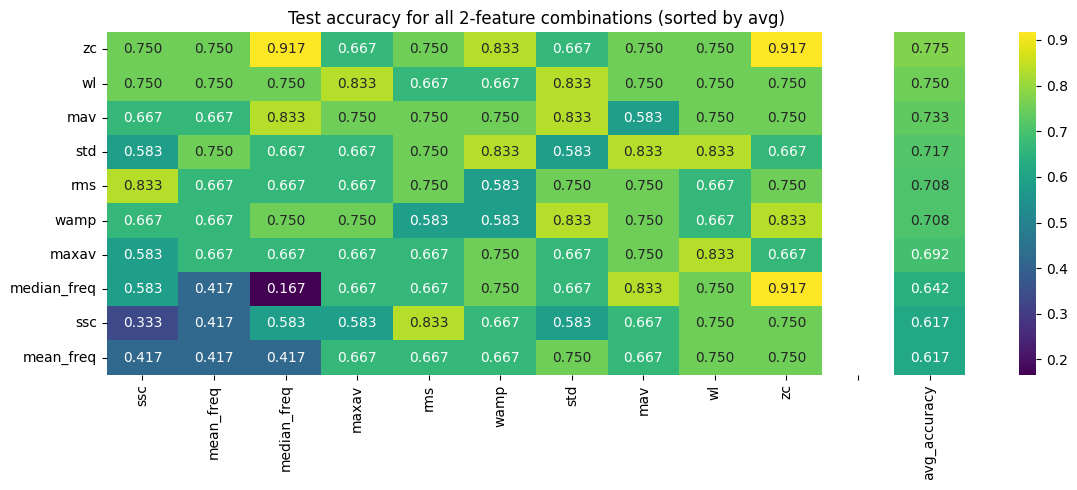

In [30]:
# Visualise the impact of selected features on classification performance, sorted by average accuracy
feature_set_size = 2
subset_df = results_df[results_df['n_features'] == feature_set_size * N_CHANNELS]
plt.figure(figsize=(12, 5))

pair_matrix = pd.DataFrame(np.nan, index=feature_names, columns=feature_names)

for _, row in subset_df.iterrows():
    f1, f2 = row["feature_set"].split("+")
    acc = row["test_accuracy"]
    pair_matrix.loc[f1, f2] = acc
    pair_matrix.loc[f2, f1] = acc

single_df = results_df[results_df["n_features"] == N_CHANNELS]
for _, row in single_df.iterrows():
    f = row["feature_set"]
    if f in pair_matrix.index:
        pair_matrix.loc[f, f] = row["test_accuracy"]

# --- Compute per-feature average accuracy ---
avg_accuracy = pair_matrix.mean(axis=1, skipna=True)

# --- Sort rows by avg accuracy ---
pair_matrix = pair_matrix.loc[avg_accuracy.sort_values(ascending=False).index]

# --- Sort columns BY the same ordering (to maintain symmetry & avoid confusion) ---
pair_matrix = pair_matrix[avg_accuracy.sort_values(ascending=False).index]

# --- Add blank spacer + avg accuracy column ---
pair_matrix[""] = np.nan
pair_matrix["avg_accuracy"] = avg_accuracy.loc[pair_matrix.index]

# final column order (sorted feature columns + spacer + avg)
pair_matrix = pair_matrix.loc[:, list(avg_accuracy.sort_values().index) + ["", "avg_accuracy"]]

# --- Recompute vmin/vmax including new columns ---
vmin = np.nanmin(pair_matrix.values)
vmax = np.nanmax(pair_matrix.values)

# --- Plot ---
plt.figure(figsize=(12, 5))
ax = plt.gca()
sns.heatmap(
    pair_matrix,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    ax=ax,
)
plt.title(f"Test accuracy for all {feature_set_size}-feature combinations (sorted by avg)")
plt.tight_layout()
plt.show()

/var/folders/5f/6pq8n0ws7c99q7szkxs11zrc0000gn/T/ipykernel_14650/4025035274.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="feature", y="test_accuracy", data=acc_df, palette="viridis_r", order=order)


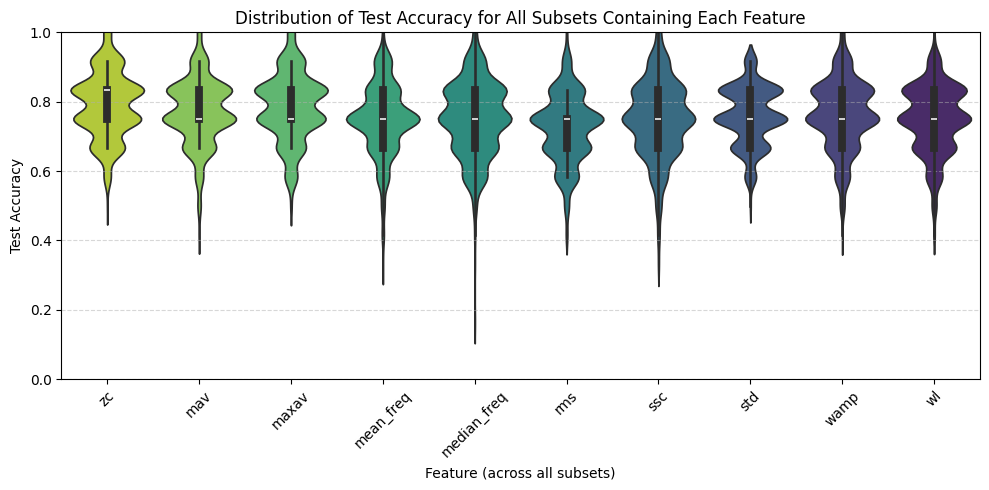

In [31]:
# Aggregate test_accuracy for every feature across all subsets, then plot as box/strip plot
rows = []
for f in feature_names:
    accs = results_df[results_df["feature_set"].str.contains(rf"\b{f}\b")]["test_accuracy"]
    rows.extend([{"feature": f, "test_accuracy": a} for a in accs])

acc_df = pd.DataFrame(rows)

# order features by descending accuracy
order = acc_df.groupby("feature")["test_accuracy"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.violinplot(x="feature", y="test_accuracy", data=acc_df, palette="viridis_r", order=order)

plt.xticks(rotation=45)
plt.ylabel("Test Accuracy")
plt.xlabel("Feature (across all subsets)")
plt.title("Distribution of Test Accuracy for All Subsets Containing Each Feature")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

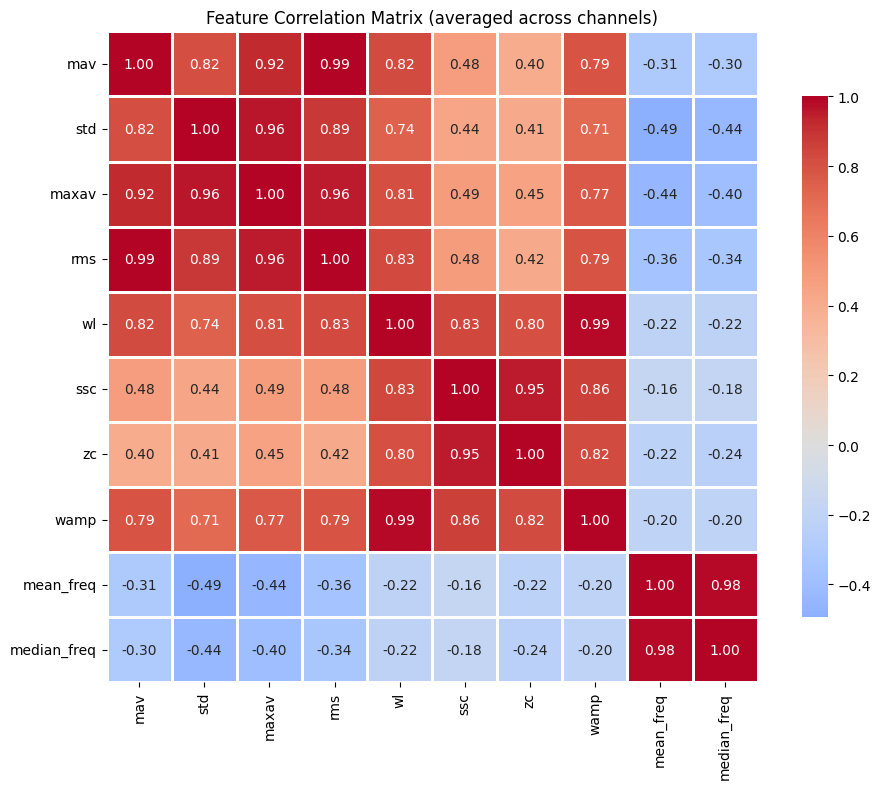


Highly correlated feature pairs (|correlation| > 0.95):
mav <-> rms: 0.992
std <-> maxav: 0.963
maxav <-> rms: 0.959
wl <-> wamp: 0.986
ssc <-> zc: 0.952
mean_freq <-> median_freq: 0.983


In [32]:
# Correlation analysis between features
# Build dataset with all features
dataset_all = build_dataset_from_precalc(precalc_features, feature_names)

# Create a DataFrame where each column represents the average of each feature across all channels
feature_avg_dict = {}
for idx, fname in enumerate(feature_names):
    start_col = idx * N_CHANNELS
    end_col = start_col + N_CHANNELS
    # Average across channels for each feature
    feature_avg_dict[fname] = dataset_all[:, start_col:end_col].mean(axis=1)

feature_df = pd.DataFrame(feature_avg_dict)

# Compute correlation matrix
corr_matrix = feature_df.corr()

# Plot correlation matrix'
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix (averaged across channels)")
plt.tight_layout()
plt.show()

threshold = 0.95
# Print highly correlated feature pairs 
print(f"\nHighly correlated feature pairs (|correlation| > {threshold}):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            print(f"{corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

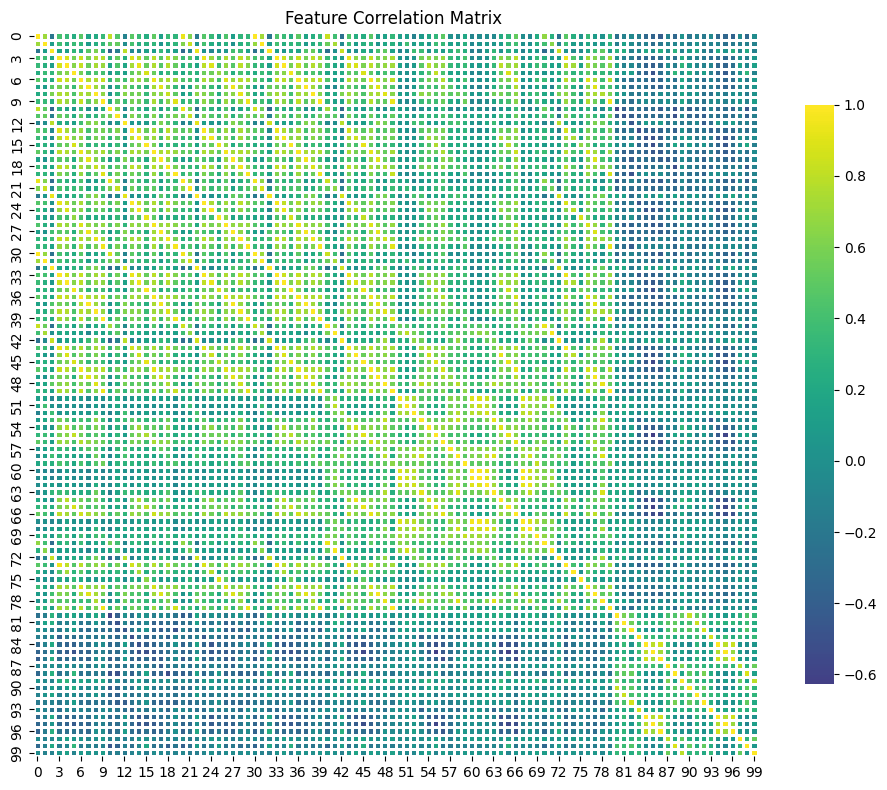


Highly correlated feature pairs (|correlation| > 0.95):
0 <-> 30: 0.994
1 <-> 31: 0.992
2 <-> 32: 0.995
3 <-> 33: 0.992
4 <-> 34: 0.988
5 <-> 35: 0.952
6 <-> 36: 0.989
6 <-> 46: 0.956
7 <-> 37: 0.994
8 <-> 38: 0.992
9 <-> 39: 0.992
13 <-> 23: 0.982
14 <-> 24: 0.963
14 <-> 34: 0.968
15 <-> 35: 0.980
16 <-> 26: 0.960
16 <-> 36: 0.980
17 <-> 27: 0.984
17 <-> 37: 0.952
18 <-> 28: 0.953
19 <-> 29: 0.969
20 <-> 30: 0.954
22 <-> 32: 0.956
23 <-> 33: 0.966
27 <-> 37: 0.972
28 <-> 38: 0.960
29 <-> 39: 0.973
36 <-> 46: 0.955
41 <-> 71: 0.967
42 <-> 72: 0.986
43 <-> 73: 0.970
47 <-> 77: 0.970
49 <-> 79: 0.982
60 <-> 61: 0.981
60 <-> 67: 0.966
61 <-> 67: 0.958
84 <-> 94: 0.990
85 <-> 95: 0.986
86 <-> 96: 0.984


In [33]:
# Correlation analysis between features
# Build dataset with all features
dataset_all = build_dataset_from_precalc(precalc_features, feature_names)
feature_df = pd.DataFrame(dataset_all)

# Compute correlation matrix
corr_matrix = feature_df.corr()

# Plot correlation matrix'
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap="viridis", center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix ")
plt.tight_layout()
plt.show()

threshold = 0.95
# Print highly correlated feature pairs 
print(f"\nHighly correlated feature pairs (|correlation| > {threshold}):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            print(f"{corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

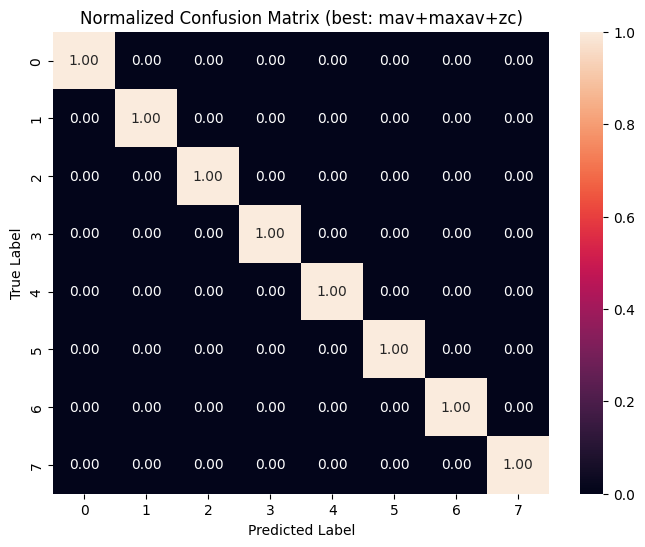

In [34]:
# Load best result and visualise normalized confusion matrix (rows sum to 1)
best_result = max(results, key=lambda r: r["test_accuracy"])
cm = np.array(best_result["confusion_matrix"], dtype=float)

# normalize by true label (rows) so each row sums to 1
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums!=0)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cbar=True)
plt.title(f'Normalized Confusion Matrix (best: {best_result["feature_set"]})')   
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Feature selection

Dataset sizes -> train: 96, val: 12, test: 12


/Users/philipp/Library/CloudStorage/OneDrive-Personal/Drive Docs/01 Education/21 EPFL/NX-421/Project 2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Feature selection consensus ranking (top rows):
       feature        mi       rfe    f_test        l1      perm  \
0          std  1.000000  0.708333  0.652435  0.947436  1.000000   
1        maxav  0.867884  0.791667  0.557629  0.766387  0.459330   
2           wl  0.983709  1.000000  0.918793  0.635580  0.000000   
3          rms  0.969118  0.583333  0.945012  0.318906  0.086124   
4          mav  0.954457  0.458333  1.000000  0.453945  0.062201   
5         wamp  0.589018  0.375000  0.752408  1.000000  0.000000   
6    mean_freq  0.183839  1.000000  0.112675  0.658625  0.019139   
7           zc  0.313064  0.000000  0.279225  0.544377  0.315789   
8          ssc  0.204341  0.416667  0.163519  0.515600  0.000000   
9  median_freq  0.000000  0.083333  0.000000  0.000000  0.320574   

   combined_score  
0        0.881814  
1        0.715794  
2        0.714923  
3        0.563620  
4        0.556427  
5        0.516245  
6        0.442780  
7        0.278222  
8        0.274724  
9 

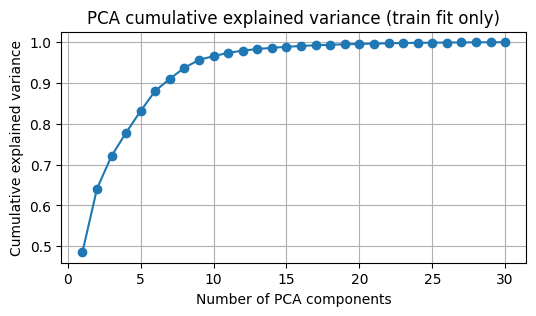

Selecting n_components = 9 (>= 95% train variance)

Baseline -> val_acc: 0.8333, test_acc: 0.8333
Reduced  -> val_acc: 0.7500, test_acc: 0.6667


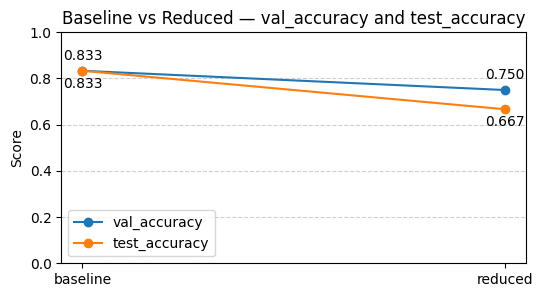

In [23]:
# Full pipeline: feature selection (enhanced), PCA, baseline vs reduced comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, RFE, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# -----------------------------
# User-configurable parameters
# -----------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.10            # proportion of full dataset used as final test
VAL_OF_REMAINDER = 0.1111  # fraction of remainder to make val ≈ 10% original (0.1111 * 0.9 ≈ 0.1)
TOP_K = 3                  # number of feature-functions to select
RFE_KEEP_RATIO = 0.5       # RFE will keep approx this fraction of columns (within training columns)
PCA_VARIANCE_THRESHOLD = 0.95

# -----------------------------
# Build dataset once
# -----------------------------
feature_names = list(all_features.keys())  # keep order deterministic
feature_funcs = [all_features[n] for n in feature_names]

X_all, y_all = build_dataset_from_ninapro(emg, stimulus, repetition, features=feature_funcs)
X_all = np.asarray(X_all)
y_all = np.asarray(y_all)

n_samples, n_total_cols = X_all.shape
assert n_total_cols % len(feature_names) == 0, (
    "Total columns must be divisible by number of feature-functions (channels per feature)."
)
N_CHANNELS = n_total_cols // len(feature_names)

# map feature -> column indices
feature_col_indices = {
    feature_names[i]: np.arange(i * N_CHANNELS, (i + 1) * N_CHANNELS)
    for i in range(len(feature_names))
}

# -----------------------------
# Stratified split: train / val / test (no leakage)
# -----------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=VAL_OF_REMAINDER, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Dataset sizes -> train: {len(y_train)}, val: {len(y_val)}, test: {len(y_test)}")

# -----------------------------
# Helper normalize function
# -----------------------------
def normalize(arr):
    arr = np.asarray(arr, dtype=float)
    if np.isclose(arr.max(), arr.min()):
        return np.ones_like(arr) * 0.5
    return (arr - arr.min()) / (arr.max() - arr.min())

# -----------------------------
# Standardize training features for methods that need it
# (We keep raw X_train for mutual_info_classif and f_classif which accept raw)
# -----------------------------
scaler_fs = StandardScaler()
X_train_z = scaler_fs.fit_transform(X_train)

# -----------------------------
# 1) Mutual Information (train set)
# -----------------------------
mi_flat = mutual_info_classif(X_train, y_train, discrete_features=False, random_state=RANDOM_STATE)
mi_scores = np.array([mi_flat[feature_col_indices[n]].mean() for n in feature_names])
mi_norm = normalize(mi_scores)

# -----------------------------
# 2) RFE with GradientBoosting (train set)
# -----------------------------
gb_for_rfe = GradientBoostingClassifier(random_state=RANDOM_STATE)
n_cols = X_train_z.shape[1]
n_keep = max(1, int(np.round(n_cols * RFE_KEEP_RATIO)))
rfe = RFE(estimator=gb_for_rfe, n_features_to_select=n_keep, step=0.1)
rfe.fit(X_train_z, y_train)
# rfe.ranking_: 1 is best (selected), larger is worse -> invert mean for higher-is-better
rfe_scores = np.array([-np.mean(rfe.ranking_[feature_col_indices[n]]) for n in feature_names])
rfe_norm = normalize(rfe_scores)

# -----------------------------
# 3) ANOVA F-test (train set)
# -----------------------------
f_vals, _ = f_classif(X_train, y_train)
f_scores = np.array([f_vals[feature_col_indices[n]].mean() for n in feature_names])
f_norm = normalize(f_scores)

# -----------------------------
# 4) L1 Logistic Regression (embedded sparse scores) (train set)
# -----------------------------
logreg = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=1.0,
    max_iter=5000,
    random_state=RANDOM_STATE,
    multi_class='ovr'
)
logreg.fit(X_train_z, y_train)
# For multi-class, coefficients shape = (n_classes, n_features); take max abs per column
coef_abs = np.abs(logreg.coef_).max(axis=0)
l1_scores = np.array([coef_abs[feature_col_indices[n]].mean() for n in feature_names])
l1_norm = normalize(l1_scores)

# -----------------------------
# 5) Permutation Importance (train set)
# -----------------------------
# Fit a fresh GB on standardized training set for permutation importances
gb_for_perm = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_for_perm.fit(X_train_z, y_train)
perm = permutation_importance(gb_for_perm, X_train_z, y_train, n_repeats=10, random_state=RANDOM_STATE, scoring='accuracy')
perm_scores = np.array([perm.importances_mean[feature_col_indices[n]].mean() for n in feature_names])
perm_norm = normalize(perm_scores)

# -----------------------------
# Combine all scores into consensus ranking
# -----------------------------
scores_df = pd.DataFrame({
    'feature': feature_names,
    'mi': mi_norm,
    'rfe': rfe_norm,
    'f_test': f_norm,
    'l1': l1_norm,
    'perm': perm_norm
})

# weights for each method (tune if you want)
weights = {'mi': 0.25, 'rfe': 0.25, 'f_test': 0.10, 'l1': 0.20, 'perm': 0.20}

scores_df['combined_score'] = (
    scores_df['mi'] * weights['mi'] +
    scores_df['rfe'] * weights['rfe'] +
    scores_df['f_test'] * weights['f_test'] +
    scores_df['l1'] * weights['l1'] +
    scores_df['perm'] * weights['perm']
)

scores_df = scores_df.sort_values('combined_score', ascending=False).reset_index(drop=True)
print("\nFeature selection consensus ranking (top rows):")
print(scores_df.head(10))

# Select TOP_K feature-functions
TOP_K = min(TOP_K, len(feature_names))
top_features = scores_df['feature'].values[:TOP_K].tolist()
print(f"\nSelected top-{TOP_K} features: {top_features}")

# -----------------------------
# Build reduced datasets (select columns) for train/val/test
# -----------------------------
selected_cols = np.hstack([feature_col_indices[f] for f in top_features])

X_train_sel = X_train[:, selected_cols]
X_val_sel = X_val[:, selected_cols]
X_test_sel = X_test[:, selected_cols]

# -----------------------------
# Scale selected features (fit scaler on training selected only)
# -----------------------------
scaler_sel = StandardScaler()
X_train_sel_z = scaler_sel.fit_transform(X_train_sel)
X_val_sel_z = scaler_sel.transform(X_val_sel)
X_test_sel_z = scaler_sel.transform(X_test_sel)

# -----------------------------
# PCA on selected features (fit on train selected)
# -----------------------------
pca = PCA(n_components=min(X_train_sel_z.shape[1], X_train_sel_z.shape[0]), random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sel_z)
X_val_pca = pca.transform(X_val_sel_z)
X_test_pca = pca.transform(X_test_sel_z)

cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(6,3))
plt.plot(np.arange(1, len(cumvar)+1), cumvar, marker='o')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA cumulative explained variance (train fit only)')
plt.grid(True)
plt.show()

# choose n components to explain >= PCA_VARIANCE_THRESHOLD (based on training cumulative variance)
if cumvar.size == 0:
    n_components = 1
else:
    idx = np.searchsorted(cumvar, PCA_VARIANCE_THRESHOLD)
    n_components = min(max(1, idx + 1), X_train_pca.shape[1])

print(f"Selecting n_components = {n_components} (>= {PCA_VARIANCE_THRESHOLD*100:.0f}% train variance)")

X_train_reduced = X_train_pca[:, :n_components]
X_val_reduced = X_val_pca[:, :n_components]
X_test_reduced = X_test_pca[:, :n_components]

# -----------------------------
# Baseline: scale using training-all then train GB
# -----------------------------
scaler_all = StandardScaler()
X_train_all_z = scaler_all.fit_transform(X_train)
X_val_all_z = scaler_all.transform(X_val)
X_test_all_z = scaler_all.transform(X_test)

clf_base = GradientBoostingClassifier(random_state=RANDOM_STATE)
clf_base.fit(X_train_all_z, y_train)
baseline_val_acc = accuracy_score(y_val, clf_base.predict(X_val_all_z))
baseline_test_acc = accuracy_score(y_test, clf_base.predict(X_test_all_z))
print(f"\nBaseline -> val_acc: {baseline_val_acc:.4f}, test_acc: {baseline_test_acc:.4f}")

# -----------------------------
# Reduced: train on PCA-reduced selected features
# -----------------------------
clf_reduced = GradientBoostingClassifier(random_state=RANDOM_STATE)
clf_reduced.fit(X_train_reduced, y_train)
reduced_val_acc = accuracy_score(y_val, clf_reduced.predict(X_val_reduced))
reduced_test_acc = accuracy_score(y_test, clf_reduced.predict(X_test_reduced))
print(f"Reduced  -> val_acc: {reduced_val_acc:.4f}, test_acc: {reduced_test_acc:.4f}")

# -----------------------------
# Final line chart (baseline vs reduced) — requested style
# -----------------------------
labels = ['baseline', 'reduced']
val_vals = [baseline_val_acc, reduced_val_acc]
test_vals = [baseline_test_acc, reduced_test_acc]

plt.figure(figsize=(6, 3))
plt.plot(labels, val_vals, marker='o', label='val_accuracy')
plt.plot(labels, test_vals, marker='o', label='test_accuracy')

for i, txt in enumerate(val_vals):
    plt.annotate(f"{txt:.3f}", (labels[i], val_vals[i]), textcoords="offset points", xytext=(0, 8), ha='center')
for i, txt in enumerate(test_vals):
    plt.annotate(f"{txt:.3f}", (labels[i], test_vals[i]), textcoords="offset points", xytext=(0, -12), ha='center')

plt.ylim(0.0, 1.0)
plt.title('Baseline vs Reduced — val_accuracy and test_accuracy')
plt.ylabel('Score')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# -----------------------------
# Expose useful objects for downstream usage
# -----------------------------
selected_feature_names = top_features
selected_feature_cols = selected_cols
pca_model = pca
scaler_selected = scaler_sel
scores_dataframe = scores_df  # ranking & per-method normalized scores